# EduPro Course Demand & Revenue Forecasting - Model Evaluation
This notebook loads the evaluation metrics and visualizes the model comparison and feature importances from the Random Forest model.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

metrics = pd.read_csv('../reports/model_evaluation_metrics.csv')
print("Model Comparison Summary:")
display(metrics)

Model Comparison Summary:


,Model,MAE,RMSE,R2,Target
0,Lasso,2.8388,3.6120,-0.0371,Static Enrollments
1,Ridge,2.8568,3.6491,-0.0585,Static Enrollments
2,Linear Regression,2.8603,3.6522,-0.0603,Static Enrollments
3,Gradient Boosting,3.0000,3.7933,-0.1438,Static Enrollments
4,XGBoost,3.2727,3.9843,-0.2619,Static Enrollments
5,Random Forest,3.3749,4.0852,-0.3266,Static Enrollments
6,Ridge,389.9290,796.2274,0.8727,Static Revenue
7,Lasso,390.8579,798.2172,0.8720,Static Revenue
8,Linear Regression,391.3754,798.4934,0.8719,Static Revenue
9,Gradient Boosting,349.2178,854.7082,0.8533,Static Revenue


### Plotting Feature Importance from Random Forest Static Revenue Model

Best model is linear. Visualizing coefficients:


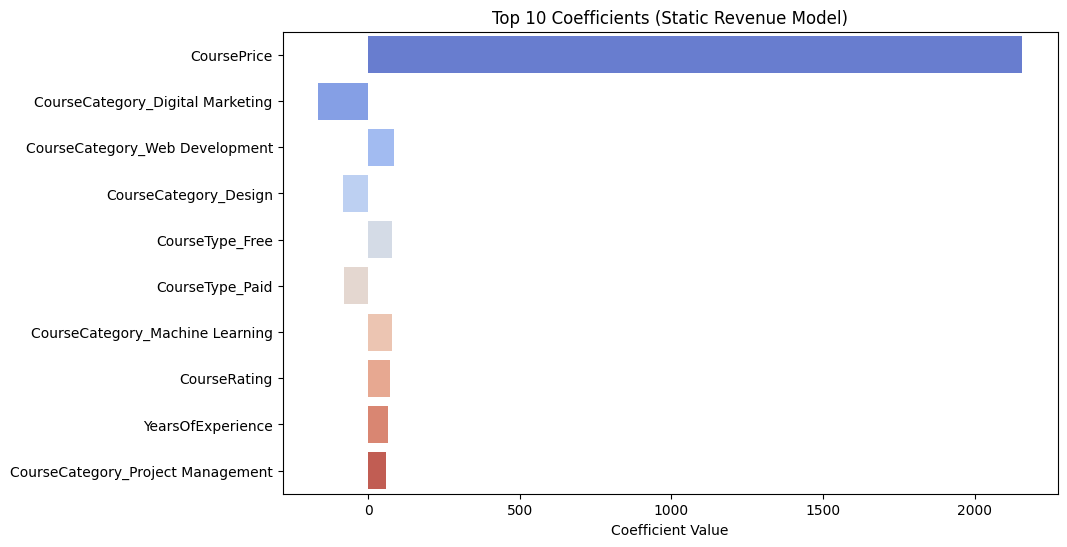

In [2]:
# Load static model and features list
with open('../models/static_revenue_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/static_features_list.pkl', 'rb') as f:
    features = pickle.load(f)

# Get importances (Works if best model is RF/GB/XGB. Ridge/Lasso has coef_ instead)
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices[:10]], y=np.array(features)[indices[:10]], palette='viridis', hue=np.array(features)[indices[:10]], legend=False)
    plt.title('Top 10 Feature Importances (Static Revenue Model)')
    plt.xlabel('Importance')
    plt.savefig('../reports/figures/feature_importances.png')
    plt.show()
else:
    print("Best model is linear. Visualizing coefficients:")
    coefs = model.coef_
    indices = np.argsort(np.abs(coefs))[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefs[indices[:10]], y=np.array(features)[indices[:10]], palette='coolwarm', hue=np.array(features)[indices[:10]], legend=False)
    plt.title('Top 10 Coefficients (Static Revenue Model)')
    plt.xlabel('Coefficient Value')
    plt.savefig('../reports/figures/feature_importances.png')
    plt.show()